In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 35

TRAIN_PATH = "dataset-1/train"
TEST_PATH = "dataset-1/test"

DATA GENERATOR

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,   # 80% train / 20% validation
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

# TRAIN
train = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# VALIDATION (from train folder)
val = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# TEST (separate)
test = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train.num_classes
class_names = list(train.class_indices.keys())

print("Classes:", class_names)

Found 4004 images belonging to 7 classes.
Found 994 images belonging to 7 classes.
Found 882 images belonging to 7 classes.
Classes: ['clapping', 'cycling', 'eating', 'hugging', 'running', 'sitting', 'sleeping']


CNN MODEL (TRANSFER LEARNING)

In [ ]:
def build_cnn():

    base = tf.keras.applications.MobileNetV2(
        input_shape=(224,224,3),
        include_top=False,
        weights='imagenet'
    )

    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(base.input, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

RNN MODEL

In [ ]:
def build_rnn():

    model = models.Sequential([
        layers.Reshape((224,224*3), input_shape=(224,224,3)),

        layers.SimpleRNN(128),

        layers.Dense(64, activation='relu'),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

LSTM MODEL

In [ ]:
def build_lstm():

    model = models.Sequential([
        layers.Reshape((224,224*3), input_shape=(224,224,3)),

        layers.LSTM(128),

        layers.Dense(64, activation='relu'),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


GRU MODEL

In [ ]:
def build_gru():

    model = models.Sequential([
        layers.Reshape((224,224*3), input_shape=(224,224,3)),

        layers.GRU(128),

        layers.Dense(64, activation='relu'),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

TRAIN ALL MODELS

In [ ]:
models_dict = {
    "CNN": build_cnn(),
    "RNN": build_rnn(),
    "LSTM": build_lstm(),
    "GRU": build_gru()
}

history_dict = {}

for name, model in models_dict.items():

    print("\nTraining:", name)

    history = model.fit(
        train,
        validation_data=val,
        epochs=EPOCHS
    )

    history_dict[name] = history

    model.save(f"single_{name}_model.h5")


Training: CNN


C:\Users\RS00046787\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 102s 781ms/step - accuracy: 0.4278 - loss: 1.5570 - val_accuracy: 0.6680 - val_loss: 1.0262
Epoch 2/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 104s 825ms/step - accuracy: 0.6356 - loss: 0.9999 - val_accuracy: 0.7183 - val_loss: 0.8335
Epoch 3/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 107s 852ms/step - accuracy: 0.6963 - loss: 0.8397 - val_accuracy: 0.7294 - val_loss: 0.7393
Epoch 4/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 105s 832ms/step - accuracy: 0.7238 - loss: 0.7667 - val_accuracy: 0.7364 - val_loss: 0.6993
Epoch 5/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 108s 860ms/step - accuracy: 0.7520 - loss: 0.7025 - val_accuracy: 0.7646 - val_loss: 0.6770
Epoch 6/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 103s 817ms/step - accuracy: 0.7567 - loss: 0.6753 - val_accuracy: 0.7736 - val_loss: 0.6625
Epoch 7/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 110s 875ms/step - accuracy: 0.7692 - loss: 0.6362 - val_accuracy: 0.7495 - val_loss: 0.6654
Epoch 8/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 115s 915ms/step - accuracy: 0.7797 -


Training: RNN
Epoch 1/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 105s 811ms/step - accuracy: 0.1908 - loss: 1.9408 - val_accuracy: 0.2324 - val_loss: 1.9087
Epoch 2/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 105s 836ms/step - accuracy: 0.2095 - loss: 1.9143 - val_accuracy: 0.2274 - val_loss: 1.8949
Epoch 3/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 105s 832ms/step - accuracy: 0.2245 - loss: 1.8900 - val_accuracy: 0.2052 - val_loss: 1.8796
Epoch 4/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 88s 695ms/step - accuracy: 0.2293 - loss: 1.8811 - val_accuracy: 0.2173 - val_loss: 1.8974
Epoch 5/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 103s 815ms/step - accuracy: 0.2368 - loss: 1.8772 - val_accuracy: 0.2656 - val_loss: 1.8584
Epoch 6/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 85s 676ms/step - accuracy: 0.2552 - loss: 1.8491 - val_accuracy: 0.2726 - val_loss: 1.8332
Epoch 7/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 84s 669ms/step - accuracy: 0.2433 - loss: 1.8614 - val_accuracy: 0.2575 - val_loss: 1.8503
Epoch 8/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 85s 674ms/step - accurac


Training: LSTM
Epoch 1/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 51s 391ms/step - accuracy: 0.1851 - loss: 1.9354 - val_accuracy: 0.2143 - val_loss: 1.9210
Epoch 2/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 52s 409ms/step - accuracy: 0.2080 - loss: 1.9157 - val_accuracy: 0.2425 - val_loss: 1.8912
Epoch 3/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 51s 404ms/step - accuracy: 0.2250 - loss: 1.8984 - val_accuracy: 0.2616 - val_loss: 1.8848
Epoch 4/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 49s 392ms/step - accuracy: 0.2375 - loss: 1.8765 - val_accuracy: 0.2475 - val_loss: 1.8788
Epoch 5/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 50s 399ms/step - accuracy: 0.2443 - loss: 1.8699 - val_accuracy: 0.2726 - val_loss: 1.8608
Epoch 6/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 50s 399ms/step - accuracy: 0.2453 - loss: 1.8650 - val_accuracy: 0.2696 - val_loss: 1.8419
Epoch 7/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 53s 417ms/step - accuracy: 0.2530 - loss: 1.8505 - val_accuracy: 0.2877 - val_loss: 1.8225
Epoch 8/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 53s 418ms/step - accuracy: 


Training: GRU
Epoch 1/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 53s 406ms/step - accuracy: 0.2045 - loss: 1.9256 - val_accuracy: 0.2596 - val_loss: 1.8677
Epoch 2/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 50s 394ms/step - accuracy: 0.2468 - loss: 1.8718 - val_accuracy: 0.2807 - val_loss: 1.8296
Epoch 3/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 55s 439ms/step - accuracy: 0.2737 - loss: 1.8229 - val_accuracy: 0.3048 - val_loss: 1.8061
Epoch 4/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 58s 457ms/step - accuracy: 0.2905 - loss: 1.7940 - val_accuracy: 0.3421 - val_loss: 1.7345
Epoch 5/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 56s 443ms/step - accuracy: 0.2890 - loss: 1.7742 - val_accuracy: 0.3410 - val_loss: 1.7309
Epoch 6/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 55s 440ms/step - accuracy: 0.3049 - loss: 1.7494 - val_accuracy: 0.3219 - val_loss: 1.7160
Epoch 7/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 55s 436ms/step - accuracy: 0.3134 - loss: 1.7276 - val_accuracy: 0.3209 - val_loss: 1.7312
Epoch 8/35
126/126 ━━━━━━━━━━━━━━━━━━━━ 59s 466ms/step - accuracy: 0

ACCURACY COMPARISON GRAPH

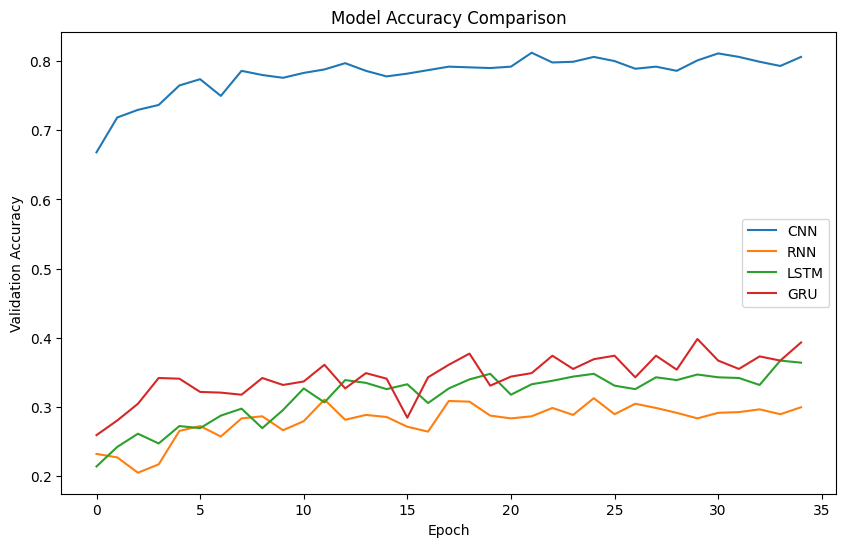

In [ ]:
plt.figure(figsize=(10,6))

for name, history in history_dict.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title("Model Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

TEST EVALUATION

In [ ]:
test.reset()

cnn_model = models_dict["CNN"]

predictions = cnn_model.predict(test)

y_pred = np.argmax(predictions, axis=1)
y_true = test.classes

28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 246ms/step


CONFUSION MATRIX

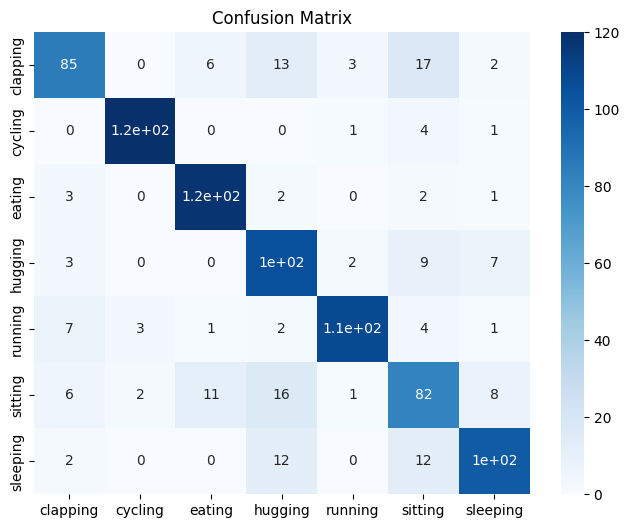

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

CLASSIFICATION REPORT

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    clapping       0.80      0.67      0.73       126
     cycling       0.96      0.95      0.96       126
      eating       0.87      0.94      0.90       126
     hugging       0.70      0.83      0.76       126
     running       0.94      0.86      0.90       126
     sitting       0.63      0.65      0.64       126
    sleeping       0.83      0.79      0.81       126

    accuracy                           0.81       882
   macro avg       0.82      0.81      0.81       882
weighted avg       0.82      0.81      0.81       882

